In [1]:
from dfbr.utils.files import get_config
from dfbr.data.dataset import BikeDemandDataset
from dfbr.models.mlp import MLP
from dfbr.eval.simmulation import Sim, create_station_dict, create_event_df
from dfbr.models.bike_rebalance import BikeRebalanceModel
from dfbr.training.train import get_loss_func, train_one_epoch, evaluate
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from torch.utils.data import DataLoader
from torch.optim import Adam

In [2]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Setup
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Read config
config = get_config("baseline.yaml")

#Create a dictionary of stations
station_dict = create_station_dict(config["paths"]["stations"], config["paths"]["station_dist_miles"], config["sim"]["start_inv_pct"])
#Sort by id to ensure alignment
station_ids = sorted(station_dict.keys())

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Load Data for Predictive Model
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Create datasets
train_ds = BikeDemandDataset(
        file = config["paths"]["input"],
        start_date = config["data"]["train_start_date"],
        end_date = config["data"]["train_end_date"],
        target_cols= [str(id) for id in station_ids],
        input_scale_cols= ['mean_temp', 'precip', 'max_gust'],
        input_no_scale_cols=['sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month']
    )

training_stats = {'mean': train_ds.mean, 'std': train_ds.std, 'y_mean': train_ds.y_mean, 'y_std': train_ds.y_std}

test_ds = BikeDemandDataset(
        file = config["paths"]["input"],
        start_date = config["data"]["test_start_date"],
        end_date = config["data"]["test_end_date"],
        target_cols= [str(id) for id in station_ids],
        input_scale_cols= ['mean_temp', 'precip', 'max_gust'],
        input_no_scale_cols=['sin_day_of_week', 'cos_day_of_week', 'sin_month', 'cos_month'],
        is_train=False,
        scaling_factor=training_stats
    )

#Wrap Data Loaders
train_dl = DataLoader(train_ds, batch_size=config["training"]["batch_size"], shuffle=False)
test_dl = DataLoader(test_ds, batch_size=config["training"]["batch_size"], shuffle=False)

In [3]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Instantiate Model and Train
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Create MLP
input_size = len(train_ds[0][0])
output_size = len(train_ds[0][1])
pred_model = MLP(input_size, output_size, config["model"]["hidden_layers"])

#Create loss function and optimizer
criterion = get_loss_func(config["training"]["loss_function"])
optimizer = Adam(pred_model.parameters(), lr=config["training"]["learning_rate"], weight_decay = config["training"]["weight_decay"])

#Training loop
for epoch in range(config["training"]["epochs"]):
    train_loss = train_one_epoch(pred_model, train_dl, optimizer, criterion, 'cpu')
    test_loss = evaluate(pred_model, test_dl, criterion, 'cpu')
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")


Epoch 1 | Train Loss: 1.0406 | Test Loss: 1.6425
Epoch 2 | Train Loss: 1.0311 | Test Loss: 1.4571
Epoch 3 | Train Loss: 0.9428 | Test Loss: 1.4820
Epoch 4 | Train Loss: 0.9516 | Test Loss: 1.4752
Epoch 5 | Train Loss: 0.9300 | Test Loss: 1.4898
Epoch 6 | Train Loss: 0.9392 | Test Loss: 1.4824
Epoch 7 | Train Loss: 0.9258 | Test Loss: 1.4896
Epoch 8 | Train Loss: 0.9298 | Test Loss: 1.4871
Epoch 9 | Train Loss: 0.9232 | Test Loss: 1.4898
Epoch 10 | Train Loss: 0.9250 | Test Loss: 1.4932
Epoch 11 | Train Loss: 0.9231 | Test Loss: 1.4898
Epoch 12 | Train Loss: 0.9183 | Test Loss: 1.4947
Epoch 13 | Train Loss: 0.9197 | Test Loss: 1.4931
Epoch 14 | Train Loss: 0.9164 | Test Loss: 1.4961
Epoch 15 | Train Loss: 0.9178 | Test Loss: 1.4940
Epoch 16 | Train Loss: 0.9152 | Test Loss: 1.4973
Epoch 17 | Train Loss: 0.9159 | Test Loss: 1.4955
Epoch 18 | Train Loss: 0.9144 | Test Loss: 1.4981
Epoch 19 | Train Loss: 0.9145 | Test Loss: 1.4968
Epoch 20 | Train Loss: 0.9131 | Test Loss: 1.4996
Epoch 21 

In [4]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Run Simulation
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#optimization model
opt_model = BikeRebalanceModel(
    station_file_path=config["paths"]["stations"],
    dist_matrix_file_path=config["paths"]["station_dist_miles"],
    loss_demand_cost=config["model"]["loss_demand_cost"],   
    over_capacity_cost=config["model"]["over_capacity_cost"],  
    movement_cost=config["model"]["movement_cost"]      
)

#Simulation
sim = Sim(
    station_dict= station_dict,
    event_df= create_event_df(config["paths"]["raw_trips"], config["paths"]["stations"], config["data"]["test_start_date"],  config["data"]["test_end_date"]),
    predict=config["sim"]["predict"],
    predict_ds=test_ds,
    predict_model= pred_model,
    opt_model=opt_model
)
sim.run()


Starting Simulation!
Simulation Complete!


System Metrics: 
Lost Demand        104.717808
Over Capacity      114.309589
Forced Returns      61.994521
Moved Bikes         65.183562
Total Inventory    616.791781
dtype: float64


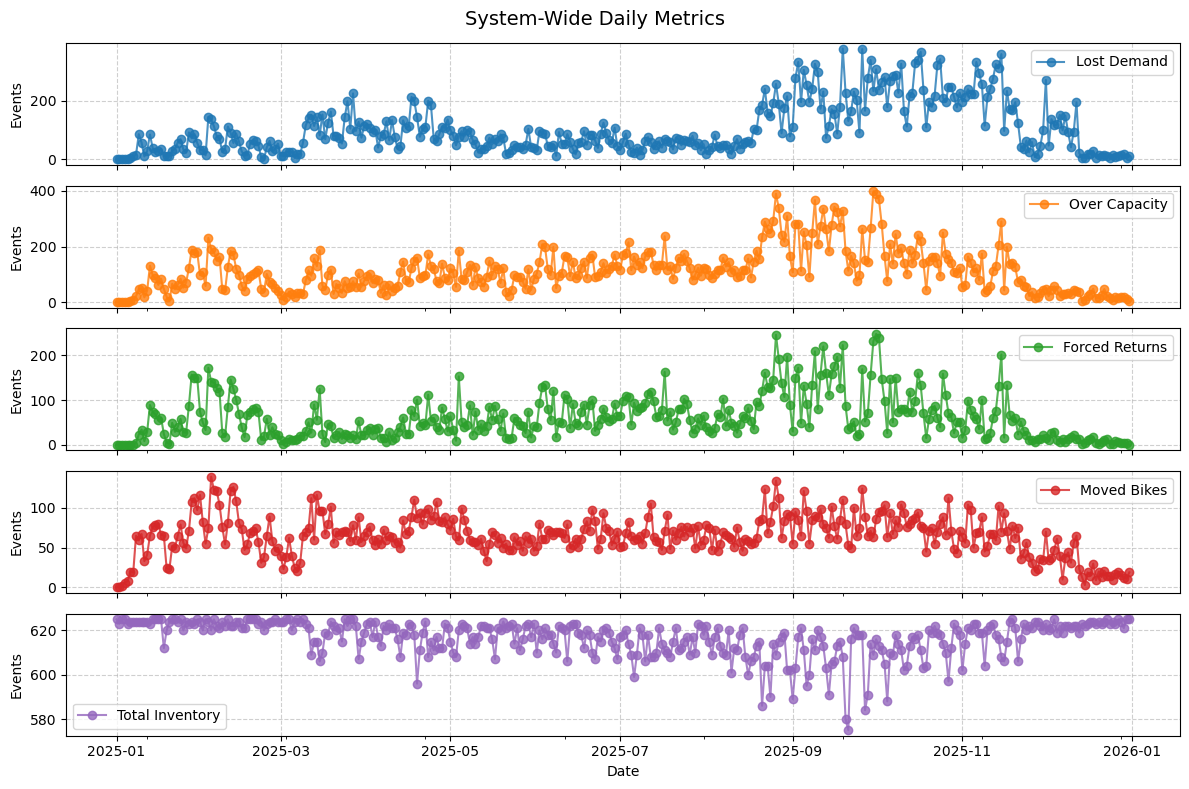

In [5]:
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
#Collect Metrics and Plot
#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
df_metrics = pd.DataFrame({
    'Lost Demand': sim.lost_demand,
    'Over Capacity': sim.over_capacity,
    'Forced Returns': sim.forced_returns,
    'Moved Bikes' : sim.moved_bikes,
    'Total Inventory' : sim.total_inventory,
    })

print(f'System Metrics: \n{df_metrics.mean()}')

axes = df_metrics.plot(
    kind='line',
    subplots=True, 
    figsize=(12, 8), 
    marker='o', 
    alpha=0.8,
    sharex=True
    )

plt.suptitle("System-Wide Daily Metrics", fontsize=14)

# Loop through each of the 3 axes to add gridlines and Y-labels
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylabel("Events")

# The X-label only needs to go on the bottom-most plot
plt.xlabel("Date")

plt.tight_layout()
plt.show()

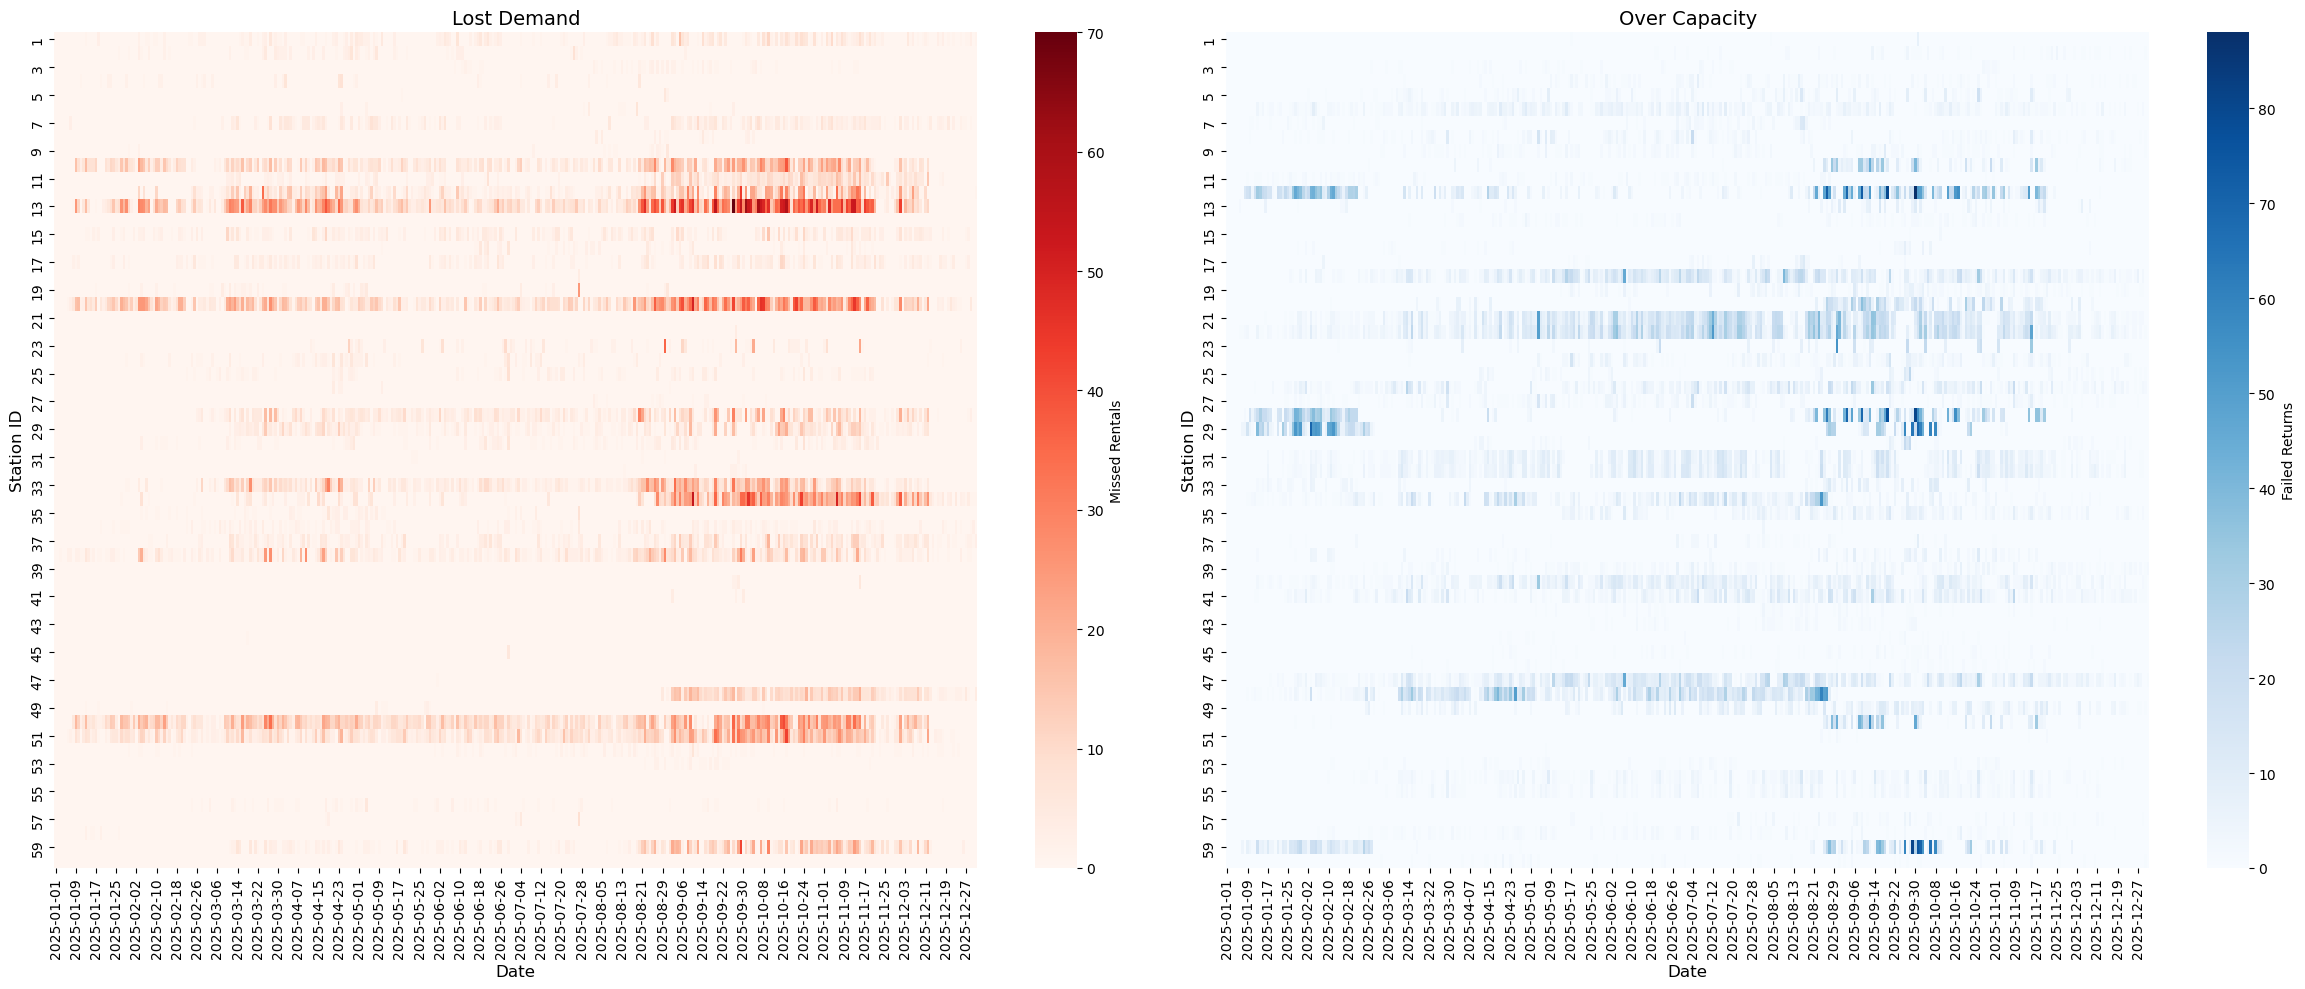

In [6]:

#Plot heatmap of station data
#Extract the nested dictionaries from the station objects
lost_demand_data = {}
over_cap_data = {}
forced_ret_data = {}

for s_id, station in sim.stations.items():
    lost_demand_data[s_id] = station.lost_demand
    over_cap_data[s_id] = station.over_capacity

# 2. Convert to DataFrames and transpose (.T) so Stations are rows and Dates are columns
df_ld = pd.DataFrame(lost_demand_data).T
df_oc = pd.DataFrame(over_cap_data).T

# Ensure the stations (Y-axis) are sorted numerically/alphabetically
df_ld.sort_index(inplace=True)
df_oc.sort_index(inplace=True)

#Set up the matplotlib figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

#Plot Lost Demand (Red)
sns.heatmap(df_ld, ax=axes[0], cmap='Reds', cbar_kws={'label': 'Missed Rentals'})
axes[0].set_title('Lost Demand', fontsize=14)
axes[0].set_ylabel('Station ID', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)

#Plot Over Capacity (Blue)
sns.heatmap(df_oc, ax=axes[1], cmap='Blues', cbar_kws={'label': 'Failed Returns'})
axes[1].set_title('Over Capacity', fontsize=14)
axes[1].set_ylabel('Station ID', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)


#Clean up layout and display
plt.tight_layout()
plt.show()

In [7]:
print(df_ld.loc[13].to_string())

2025-01-01     0
2025-01-02     0
2025-01-03     0
2025-01-04     0
2025-01-05     0
2025-01-06     0
2025-01-07     0
2025-01-08     1
2025-01-09    25
2025-01-10    11
2025-01-11     0
2025-01-12     6
2025-01-13    17
2025-01-14     5
2025-01-15     0
2025-01-16     0
2025-01-17     1
2025-01-18     0
2025-01-19     0
2025-01-20     3
2025-01-21     4
2025-01-22     6
2025-01-23     9
2025-01-24    15
2025-01-25     7
2025-01-26     9
2025-01-27    26
2025-01-28    18
2025-01-29    27
2025-01-30    10
2025-01-31     3
2025-02-01     1
2025-02-02     1
2025-02-03    30
2025-02-04    28
2025-02-05    27
2025-02-06    19
2025-02-07    23
2025-02-08     0
2025-02-09     9
2025-02-10    21
2025-02-11    16
2025-02-12    14
2025-02-13    18
2025-02-14    17
2025-02-15     0
2025-02-16     0
2025-02-17     0
2025-02-18    11
2025-02-19    14
2025-02-20     9
2025-02-21     8
2025-02-22     0
2025-02-23     0
2025-02-24     7
2025-02-25    14
2025-02-26     5
2025-02-27     7
2025-02-28    

In [8]:
print(df_oc.loc[29].to_string())

2025-01-01     0
2025-01-02     0
2025-01-03     0
2025-01-04     0
2025-01-05     0
2025-01-06     0
2025-01-07     2
2025-01-08     3
2025-01-09    15
2025-01-10     5
2025-01-11     2
2025-01-12     0
2025-01-13    39
2025-01-14    24
2025-01-15    23
2025-01-16     9
2025-01-17    17
2025-01-18     3
2025-01-19     3
2025-01-20     0
2025-01-21    12
2025-01-22     0
2025-01-23    30
2025-01-24    20
2025-01-25     0
2025-01-26     6
2025-01-27    35
2025-01-28    52
2025-01-29    44
2025-01-30    49
2025-01-31    10
2025-02-01     4
2025-02-02     0
2025-02-03    67
2025-02-04    46
2025-02-05    53
2025-02-06    51
2025-02-07    41
2025-02-08     1
2025-02-09     4
2025-02-10    46
2025-02-11    48
2025-02-12    52
2025-02-13    40
2025-02-14    23
2025-02-15     1
2025-02-16     4
2025-02-17    16
2025-02-18    20
2025-02-19    19
2025-02-20    21
2025-02-21     1
2025-02-22     0
2025-02-23     9
2025-02-24    10
2025-02-25     0
2025-02-26     0
2025-02-27     0
2025-02-28    

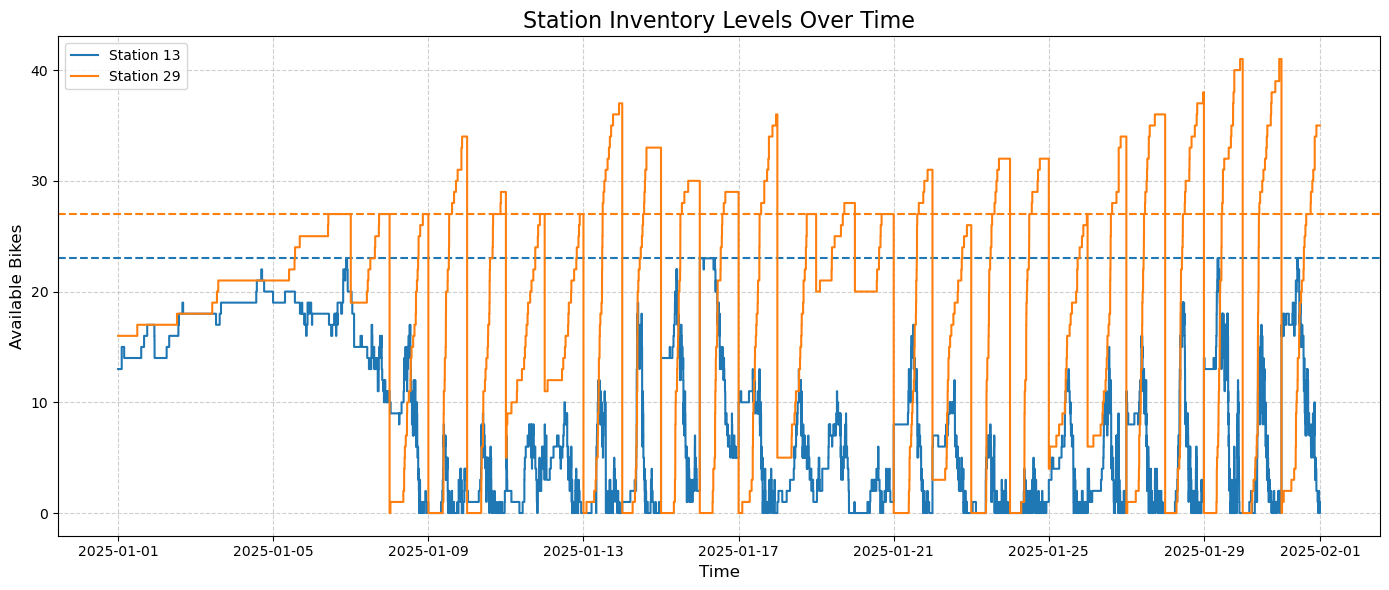

In [10]:
#Flatten the history from all objects into a single list of dictionaries
stations_to_plot = [13,29]

all_records = [
    {'time': record['time'], 'station_id': s.id, 'inventory': record['inventory']}
    for s_id, s in sim.stations.items() 
    if s_id in stations_to_plot
    for record in s.history
]

# 2. Convert to DataFrame
df_inv = pd.DataFrame(all_records)

# 3. Pivot and forward-fill (ffill) to make it a continuous time-series
# Columns will be station_ids, Index will be time, Values will be inventory
df_inv_pivot = df_inv.pivot_table(
    index='time', 
    columns='station_id', 
    values='inventory', 
    aggfunc='last'
).ffill()
df_inv_pivot = df_inv_pivot.loc['2025-01-01': '2025-01-31']
# 4. Plotting

plt.figure(figsize=(14, 6))

for s_id in df_inv_pivot:
   line, = plt.step(
        df_inv_pivot.index, 
        df_inv_pivot[s_id], 
        where='post', # 'post' ensures the step drops/rises exactly at the event time
        label=f'Station {s_id}'
    )
   current_color = line.get_color()
   plt.axhline(y = station_dict.get(s_id).capacity, color=current_color, linestyle='--', label=f'_Station {s_id} Cap')

plt.title('Station Inventory Levels Over Time', fontsize=16)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Available Bikes', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [9]:
#Read the file
df = pd.read_parquet(config["paths"]["input"], engine='pyarrow')
print(df.loc['2025-01-01': '2025-01-31', ['13']])

                             13
2025-01-01 00:00:00-05:00   1.0
2025-01-02 00:00:00-05:00   4.0
2025-01-03 00:00:00-05:00   1.0
2025-01-04 00:00:00-05:00   0.0
2025-01-05 00:00:00-05:00  -2.0
2025-01-06 00:00:00-05:00   6.0
2025-01-07 00:00:00-05:00  -7.0
2025-01-08 00:00:00-05:00  -6.0
2025-01-09 00:00:00-05:00   0.0
2025-01-10 00:00:00-05:00   3.0
2025-01-11 00:00:00-05:00   3.0
2025-01-12 00:00:00-05:00  -8.0
2025-01-13 00:00:00-05:00   5.0
2025-01-14 00:00:00-05:00   1.0
2025-01-15 00:00:00-05:00  -3.0
2025-01-16 00:00:00-05:00  -3.0
2025-01-17 00:00:00-05:00   1.0
2025-01-18 00:00:00-05:00   0.0
2025-01-19 00:00:00-05:00   4.0
2025-01-20 00:00:00-05:00   2.0
2025-01-21 00:00:00-05:00  -4.0
2025-01-22 00:00:00-05:00   2.0
2025-01-23 00:00:00-05:00   1.0
2025-01-24 00:00:00-05:00   0.0
2025-01-25 00:00:00-05:00   1.0
2025-01-26 00:00:00-05:00  -2.0
2025-01-27 00:00:00-05:00 -11.0
2025-01-28 00:00:00-05:00   2.0
2025-01-29 00:00:00-05:00 -14.0
2025-01-30 00:00:00-05:00   2.0
2025-01-

In [26]:
trips = create_event_df(config["paths"]["raw_trips"], config["paths"]["stations"], config["data"]["test_start_date"],  config["data"]["test_end_date"])
trips = trips[trips['station_id'] == 13]
trips.set_index('time', inplace=True)
trips['inventory'] = trips['event_type'].map({'return' : 1, 'rent' : -1})

<Axes: xlabel='time'>

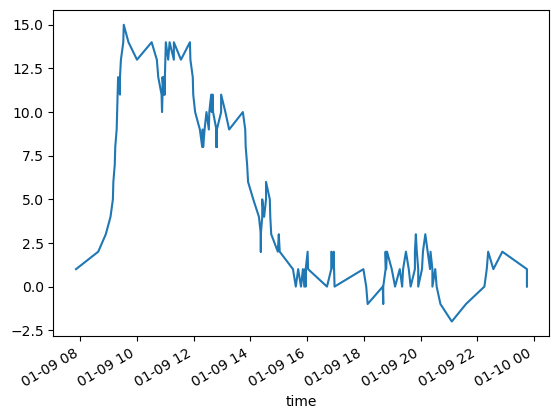

In [30]:
trips = trips['2025-01-09': '2025-01-09']
trips['running_inventory'] = trips['inventory'].cumsum()
trips['running_inventory'] .plot()

<Axes: xlabel='time'>

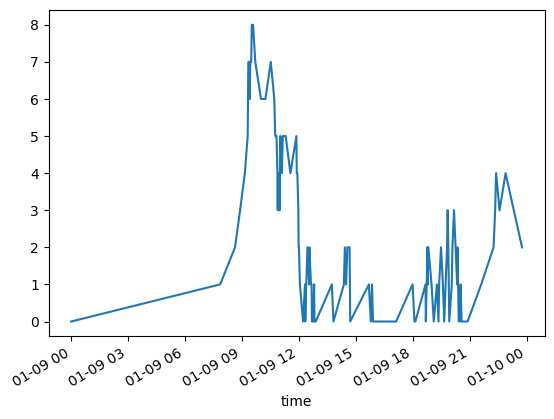

In [36]:
df_inv_pivot[13].plot()